# GNN Models 1–4 — Training Diagnostics

Renders training curves and held-out-test diagnostics for the four
`LineupGNN` variants in the 2 × 2 grid (kind × mode):

| key | `kind` | `mode` |
|---|---|---|
| `position_single`  | position  | single |
| `archetype_single` | archetype | single |
| `position_paired`  | position  | paired |
| `archetype_paired` | archetype | paired |

Each model is trained by `scripts/train_gnn.py --kind <k> --mode <m>`,
which reads the shared match-blocked split
(`data/processed/{train,test}_snapshots.parquet`) produced by
`scripts/build_train_test_split.py`. Per-epoch metrics on the held-out
test parquet, the best-epoch test predictions, and a frozen
hyperparameter snapshot are written to
`artifacts/gnn_<kind>_<mode>/`. The internal `val_*` naming in the log
files is a Pytorch carryover — it refers to the test set throughout.

This notebook is intentionally thin — every plotting helper lives in
`models.training_plots` so the analysis can be reused outside Jupyter.

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

HERE = Path.cwd()
ROOT = HERE
while ROOT != ROOT.parent and not (ROOT / 'configs' / 'config.yaml').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from models.training_plots import (
    MODEL_KEYS,
    PRETTY_LABEL,
    load_all_runs,
    plot_calibration,
    plot_loss_curves,
    plot_metric_overlays,
    plot_pred_vs_target_grid,
    plot_residual_hists,
    summary_table,
)

pd.set_option('display.width', 220)
ARTIFACTS = ROOT / 'artifacts'
print(f'reading runs from {ARTIFACTS}/')

reading runs from c:\Users\zcoch\dsc_148\DSC 148 Final Project\artifacts/


In [2]:
runs = load_all_runs(ARTIFACTS)
missing = [k for k in MODEL_KEYS if k not in runs]
print(f'loaded {len(runs)} run(s): {sorted(runs)}')
if missing:
    print(f'missing: {missing} — train with `python -m scripts.train_gnn --kind <k> --mode <m>`')

loaded 4 run(s): ['archetype_paired', 'archetype_single', 'position_paired', 'position_single']


## Summary table

Best-epoch metrics per model (lowest validation MSE).

In [3]:
summary_table(runs)

,best epoch,val MSE,val MAE,val R²,val Pearson r,val sign acc
model,,,,,,
"position, single",28,0.8324,0.5307,0.0069,0.0871,0.4488
"archetype, single",30,0.7380,0.5427,0.1194,0.3461,0.6012
"position, paired",10,0.8336,0.5312,0.0054,0.0763,0.4450
"archetype, paired",29,0.7357,0.5412,0.1222,0.3505,0.6012


## Train vs validation MSE

One panel per model. Dashed line is validation; the highlighted dot marks the
best validation epoch (the checkpoint saved to disk).

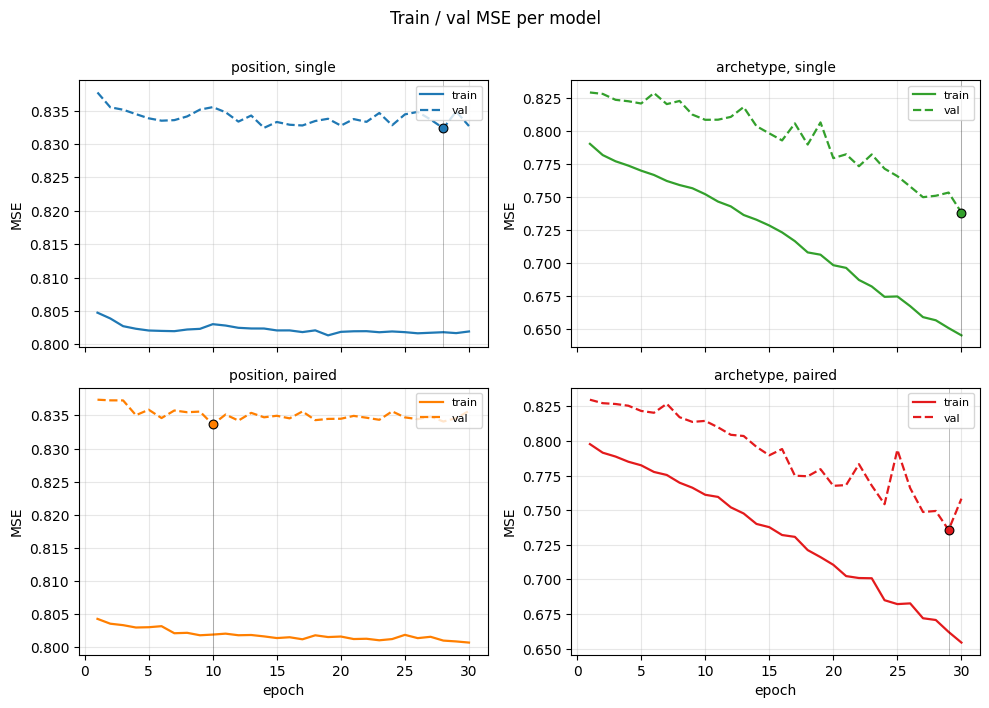

In [4]:
fig = plot_loss_curves(runs); plt.show()

## Validation metric overlays

All 4 models on one axis per metric so absolute differences (and how fast
they converge) are directly comparable.

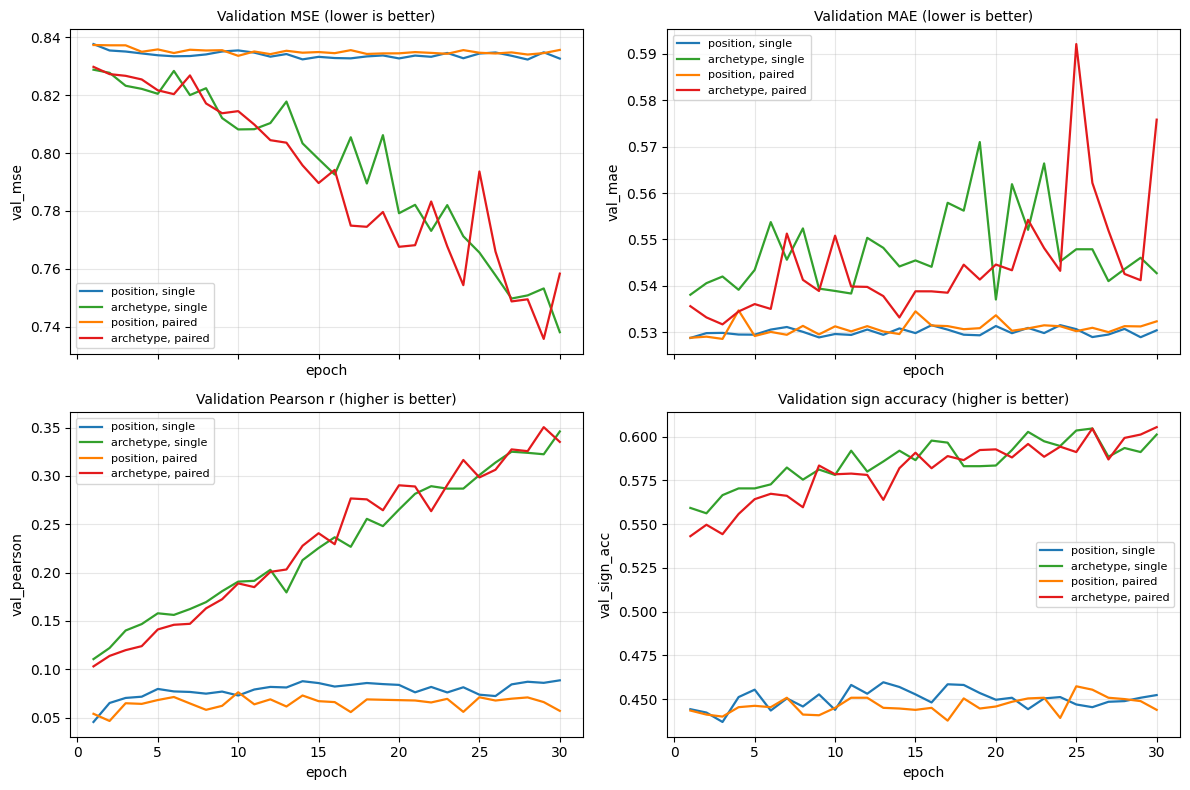

In [5]:
fig = plot_metric_overlays(
    runs,
    metrics=('val_mse', 'val_mae', 'val_pearson', 'val_sign_acc'),
)
plt.show()

## Optimization health

Gradient norm and learning rate per epoch. A grad norm that explodes or
collapses is the easiest signal that something is off with the optimizer.

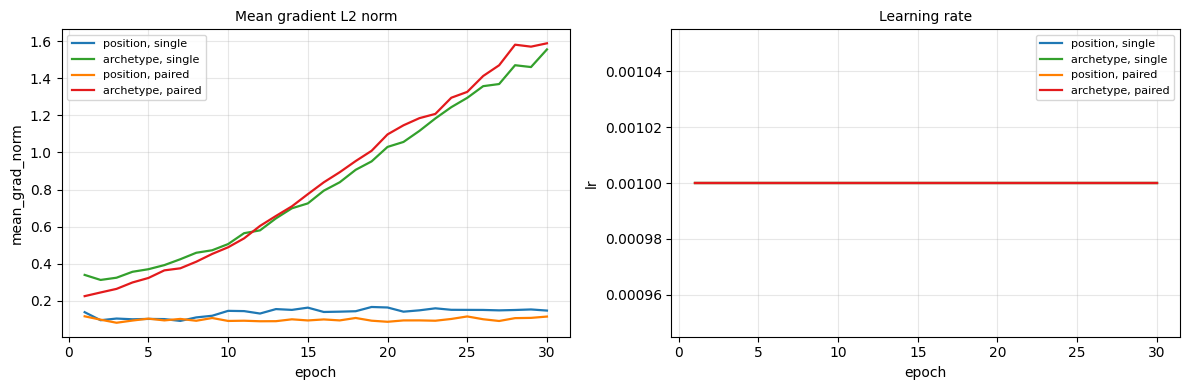

In [6]:
fig = plot_metric_overlays(
    runs,
    metrics=('mean_grad_norm', 'lr'),
    metric_titles={'lr': 'Learning rate'},
    figsize=(12, 4),
)
plt.show()

## Predictions vs targets (best epoch)

Dashed diagonal is the ideal calibration line. Pearson `r` in the title
summarises rank-consistency between predicted and observed differentials.

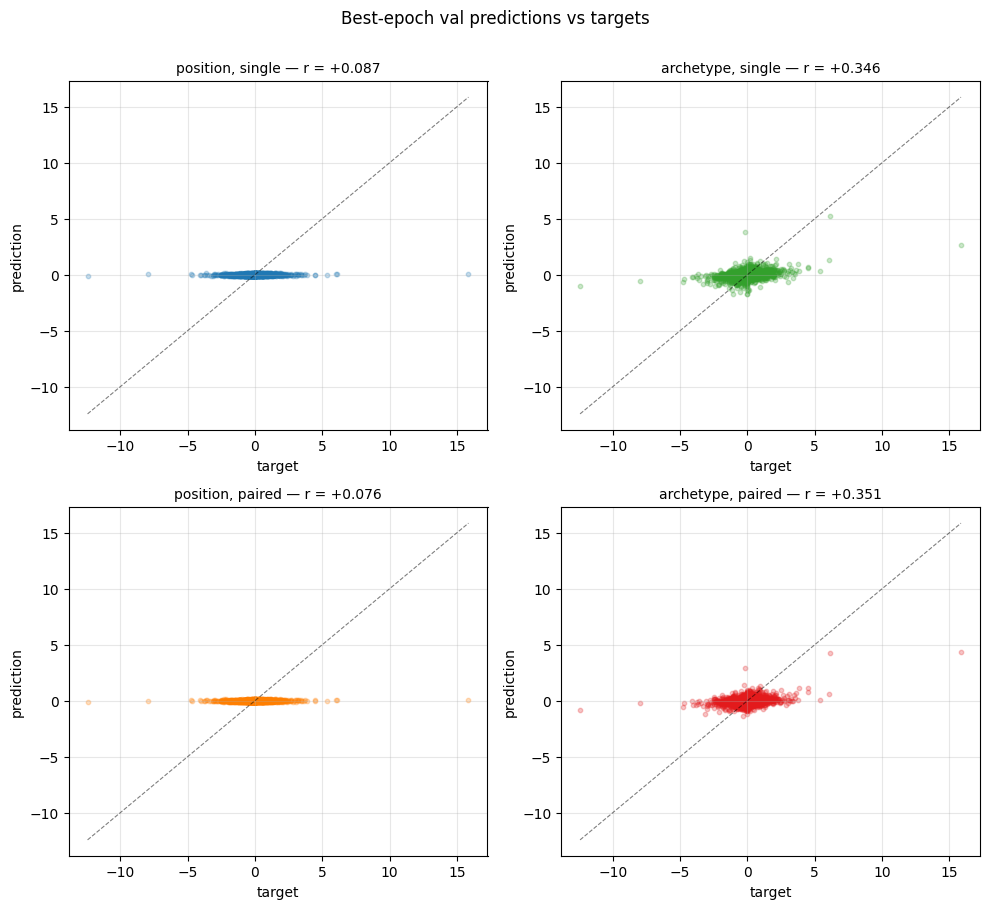

In [7]:
fig = plot_pred_vs_target_grid(runs); plt.show()

## Residual distributions (best epoch)

If a model's residual mean is meaningfully nonzero the head has a
systematic bias; the spread is an MSE-free view of how concentrated
the errors are.

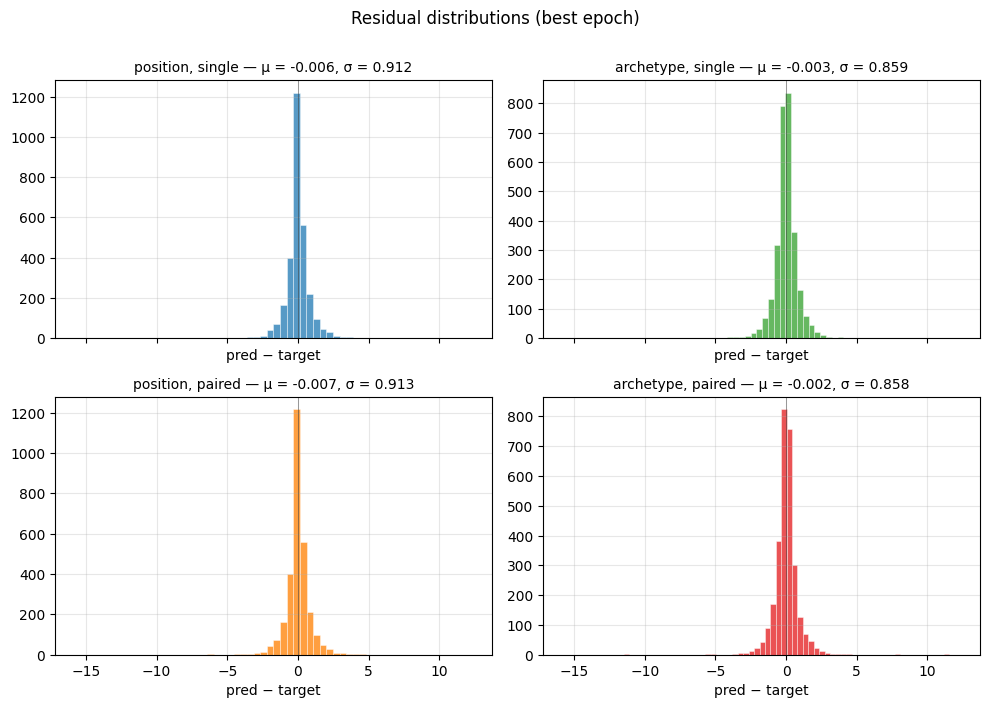

In [8]:
fig = plot_residual_hists(runs); plt.show()

## Reliability (mean target vs mean prediction by decile)

Sort predictions, bin into deciles, and plot (bin mean prediction, bin mean
target). A perfectly calibrated regressor sits on the diagonal.

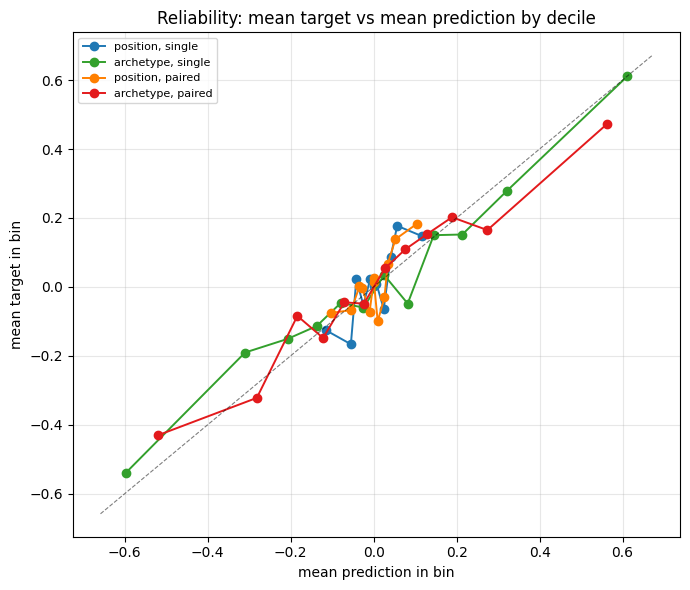

In [9]:
fig = plot_calibration(runs); plt.show()